We are importing libraries below

In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load the dataset

In [55]:
# Load dataset
data_path = "../data/webscrapped_raw_dataset/fashion_trend_weekly_dataset_2021_2025.csv"

df = pd.read_csv(data_path)

# basic info
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1434, 26)


,week,year,month,season,category,search_index,search_growth,momentum_4w,keyword_frequency,brand_popularity,...,dark_ratio,bright_ratio,pattern_printed_ratio,pattern_plain_ratio,image_count,availability_count,discount_avg,new_arrival_ratio,trend_label,next_week_search
0,1,2021,1,Winter,Hoodie,51.38,0.000000,52.510,157,0.63,...,0.55,0.00,0.11,0.89,283,293,0.16,0.15,1,54.73
1,2,2021,1,Winter,Hoodie,54.73,0.065200,52.510,157,0.84,...,0.30,0.37,0.31,0.69,281,299,0.21,0.17,2,48.89
2,3,2021,1,Winter,Hoodie,48.89,-0.106706,52.510,151,0.77,...,0.52,0.04,0.20,0.80,232,262,0.17,0.09,0,55.04
3,4,2021,1,Winter,Hoodie,55.04,0.125793,52.510,153,0.54,...,0.44,0.00,0.10,0.90,259,296,0.16,0.16,2,56.72
4,5,2021,2,Winter,Hoodie,56.72,0.030523,53.845,150,0.46,...,0.70,0.00,0.13,0.87,252,329,0.21,0.09,1,62.65


### Dataset Structure Inspection

In this step, we inspect the dataset structure to understand:

* Data types of each column
* Number of non-null values
* Whether any columns contain missing data

This helps identify potential data cleaning requirements before performing deeper exploratory analysis.


In [56]:
# Dataset structure overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1434 entries, 0 to 1433
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   week                   1434 non-null   int64  
 1   year                   1434 non-null   int64  
 2   month                  1434 non-null   int64  
 3   season                 1434 non-null   str    
 4   category               1434 non-null   str    
 5   search_index           1434 non-null   float64
 6   search_growth          1434 non-null   float64
 7   momentum_4w            1434 non-null   float64
 8   keyword_frequency      1434 non-null   int64  
 9   brand_popularity       1434 non-null   float64
 10  avg_price              1434 non-null   float64
 11  avg_rating             1434 non-null   float64
 12  cotton_ratio           1434 non-null   float64
 13  printed_ratio          1434 non-null   float64
 14  oversized_ratio        1434 non-null   float64
 15  pastel_ratio   

### Interpretation

The `df.info()` output provides important insights about the dataset:

* Total number of records: **1434**
* Total number of features: **26**

The data types reveal the structure of the dataset:

* **Numerical features**: search metrics, ratios, prices, counts, etc.
* **Categorical features**: `season`, `category`
* **Temporal features**: `week`, `year`, `month`

From this inspection we will also verify:

* Whether any columns contain **missing values**
* Whether categorical variables require **encoding**
* Whether numeric variables need **scaling or normalization**

This step helps prepare for the next stage: **missing value analysis and feature distribution visualization**.


### Missing Value Analysis

Before performing deeper exploratory analysis, it is important to verify whether the dataset contains missing values.

Missing values can negatively impact machine learning models by introducing bias or reducing training effectiveness.

In this step we compute the number of missing values per feature and visualize them to confirm the dataset's completeness.


In [57]:
# Missing value check
missing_values = df.isnull().sum()

missing_values

week                     0
year                     0
month                    0
season                   0
category                 0
search_index             0
search_growth            0
momentum_4w              0
keyword_frequency        0
brand_popularity         0
avg_price                0
avg_rating               0
cotton_ratio             0
printed_ratio            0
oversized_ratio          0
pastel_ratio             0
dark_ratio               0
bright_ratio             0
pattern_printed_ratio    0
pattern_plain_ratio      0
image_count              0
availability_count       0
discount_avg             0
new_arrival_ratio        0
trend_label              0
next_week_search         0
dtype: int64

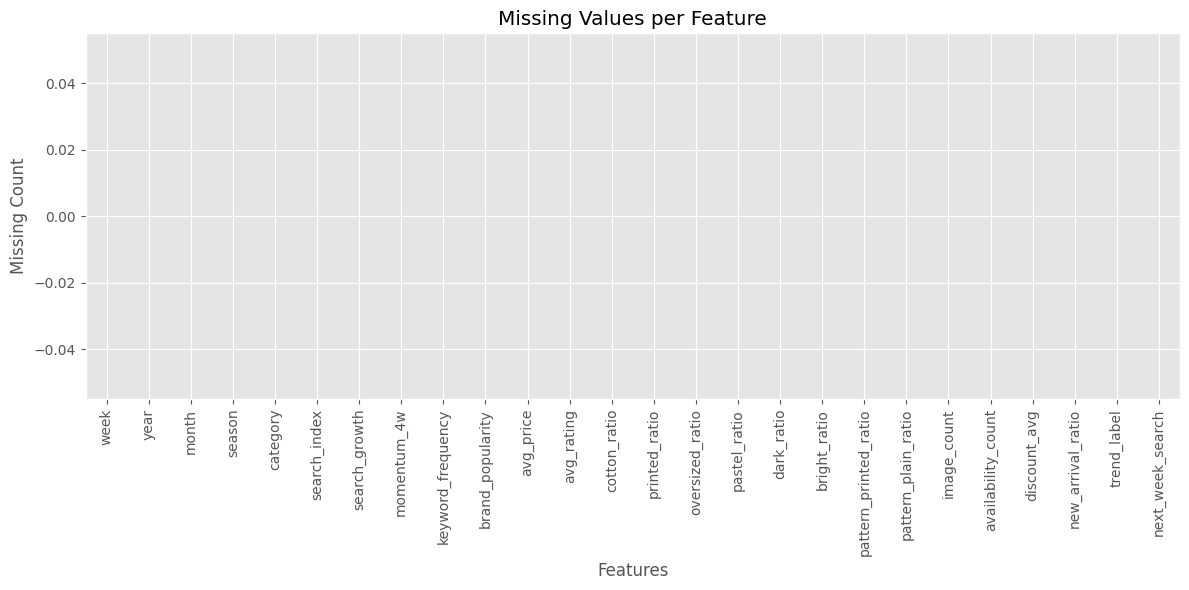

In [58]:
plt.figure(figsize=(12,6))

missing_values.plot(kind='bar')

plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Missing Count")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../reports/missing_values_analysis.png")
plt.show()
plt.close()

### Interpretation

The missing value analysis shows that all features contain complete data with no missing entries.

This indicates that the dataset has already been well-preprocessed during earlier pipeline stages such as scraping, NLP processing, and computer vision feature extraction.

Because the dataset is complete:

* No imputation techniques (mean, median, interpolation) are required.
* The model training process can proceed without concerns related to missing data.

This confirms that the dataset is structurally ready for further exploratory analysis and feature evaluation.


### Target Variable Exploration

Before building machine learning models, it is essential to understand the behavior of the target variables.

This dataset contains two prediction targets:

* **trend_label** → classification target representing whether a fashion item is declining, stable, or trending.
* **next_week_search** → regression target representing the expected search demand for the following week.

Analyzing these variables helps determine:

* whether the classification labels are balanced
* the distribution of future demand values
* whether transformations may be required later.


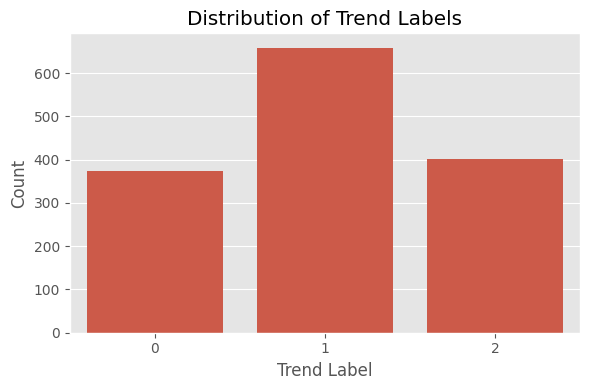

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["trend_label"])

plt.title("Distribution of Trend Labels")
plt.xlabel("Trend Label")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/trend_label_distribution.png")
plt.show()
plt.close()

### Interpretation

This visualization shows the distribution of the **trend_label** classes.

Ideally, the classes should be reasonably balanced. If one class dominates the dataset, machine learning models may become biased toward predicting that class.

Understanding this distribution helps determine whether techniques such as class weighting or resampling might be required during model training.


### Distribution of Next Week Search Demand

The variable `next_week_search` represents the predicted demand signal for the following week.

Understanding its distribution helps determine whether the regression target is normally distributed or skewed, which may influence later modeling and transformations.


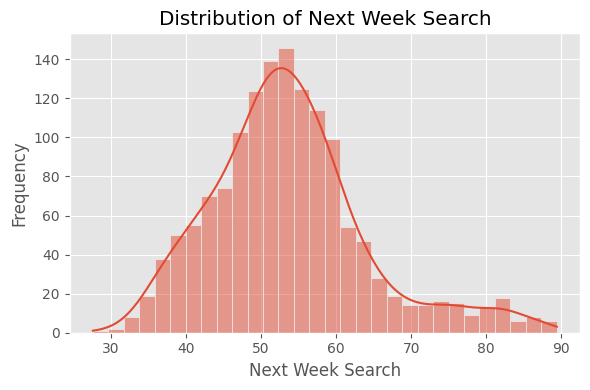

In [60]:
plt.figure(figsize=(6,4))

sns.histplot(df["next_week_search"], bins=30, kde=True)

plt.title("Distribution of Next Week Search")
plt.xlabel("Next Week Search")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../reports/next_week_search_distribution.png")

plt.show()

plt.close()

### Interpretation

The distribution of `next_week_search` appears approximately **bell-shaped (near normal distribution)** with most values concentrated between **45 and 60**.

Key observations:

* The majority of weekly search demand falls in the **mid-range**, indicating stable consumer interest levels.
* Very low (<35) and very high (>75) search values occur less frequently.
* The presence of a few higher values suggests occasional **trend spikes** where certain fashion categories gain sudden popularity.

Because the distribution is reasonably smooth and not extremely skewed, the dataset is suitable for regression modeling without requiring heavy transformation at this stage.


### Feature Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset.

By visualizing correlations, we can detect:

* features that strongly influence the prediction targets
* redundant variables that may provide similar information
* potential multicollinearity issues.

A correlation heatmap provides a quick overview of how all numerical variables relate to each other.


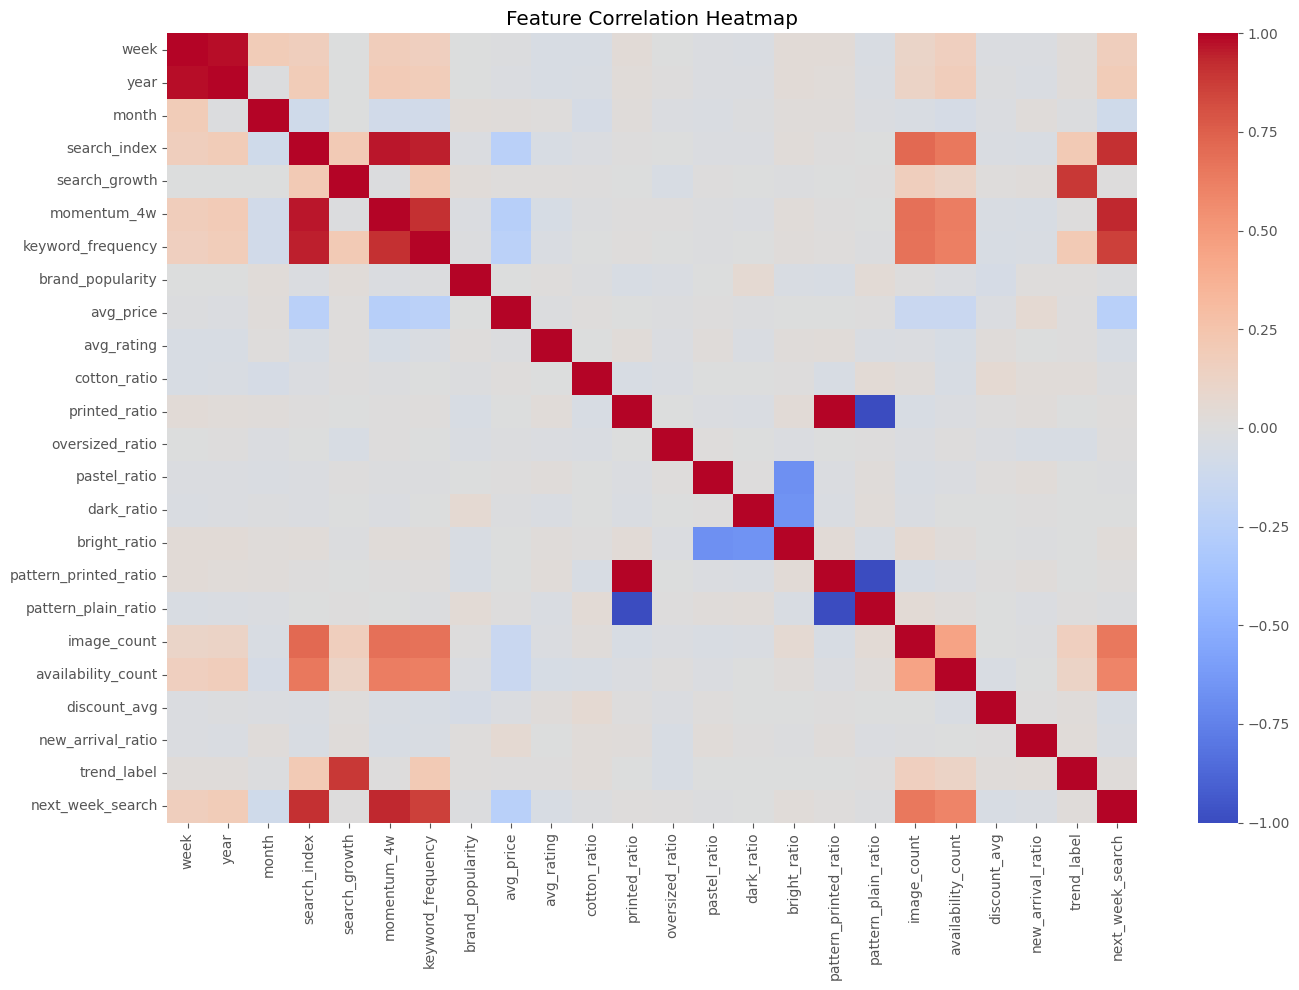

In [61]:
plt.figure(figsize=(14,10))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig("../reports/correlation_heatmap.png")

plt.show()

plt.close()

### Interpretation

The correlation heatmap provides an overview of relationships between numerical variables in the dataset.

Several important observations can be made:

Strong positive correlations are visible between **search_index, keyword_frequency, and momentum_4w**. This suggests that these variables collectively represent consumer interest signals and likely move together when fashion demand increases.

The variable **next_week_search** shows relatively strong positive relationships with **search_index, momentum_4w, keyword_frequency, and image_count**, indicating that current search demand and visual activity are important predictors of future demand.

Moderate correlation is also visible between **image_count and availability_count**, which makes sense because increased product listings or catalog availability often correspond with higher visual presence online.

Most of the style-related variables (cotton_ratio, pastel_ratio, bright_ratio, oversized_ratio, etc.) show weaker correlations with the demand variables. This suggests that these features may capture stylistic characteristics rather than direct demand signals.

Overall, the heatmap indicates that **consumer interest metrics and visual activity signals are the strongest drivers of future search demand**, making them important predictors for the trend forecasting model.


### Numerical Feature Distributions

Understanding the distribution of numerical variables is an important step in exploratory data analysis.

Histograms help visualize:

* the spread of values
* skewness in distributions
* potential outliers
* whether transformations may be required.

Analyzing these distributions helps determine how the data behaves before applying machine learning models.


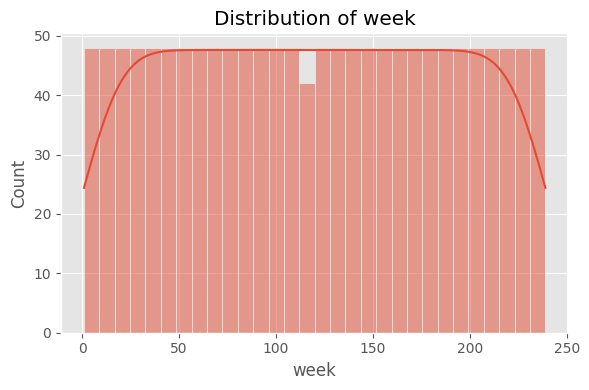

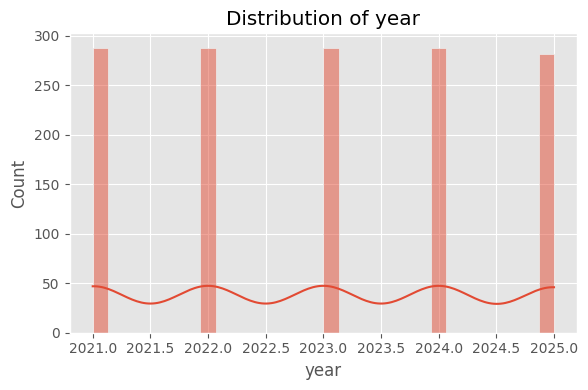

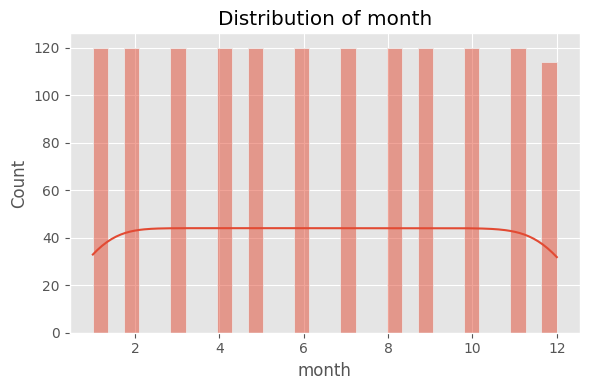

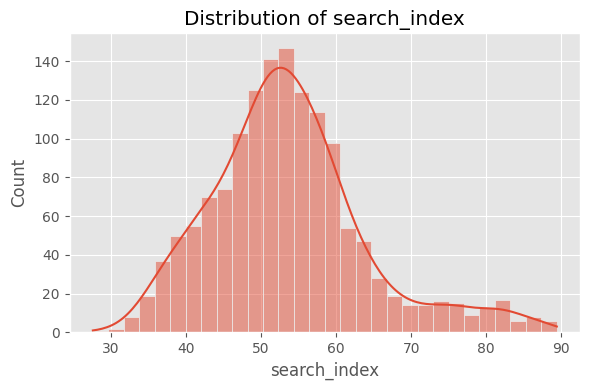

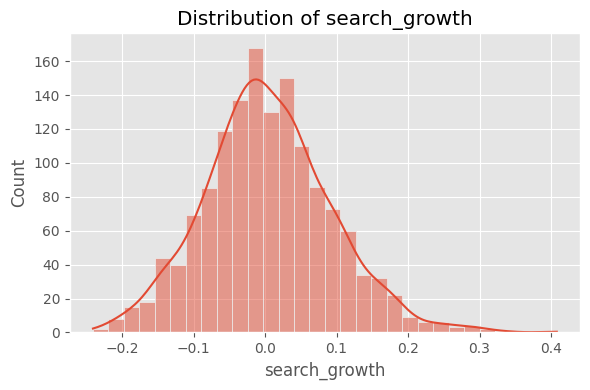

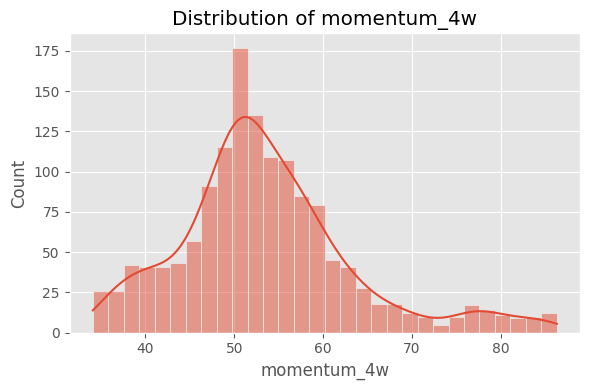

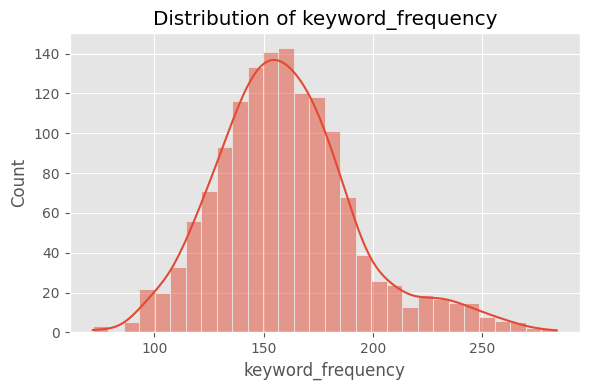

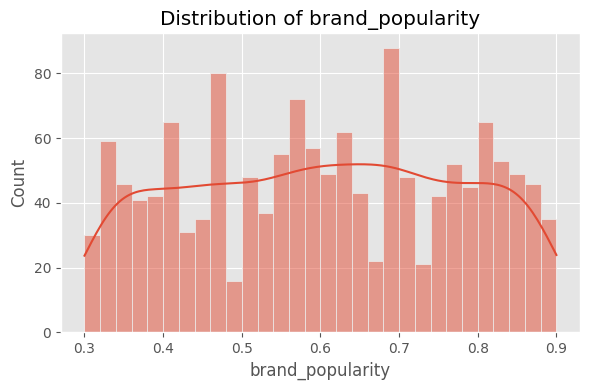

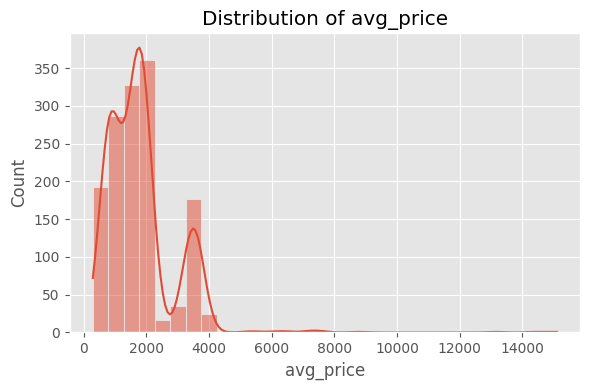

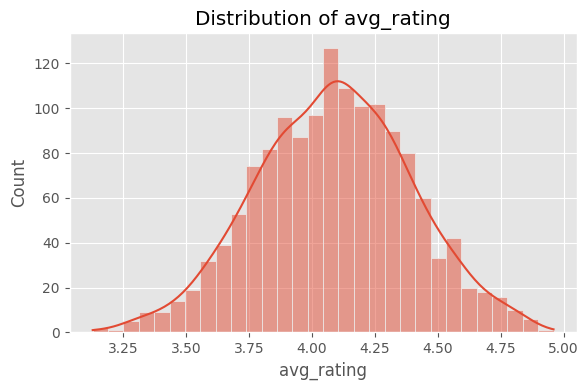

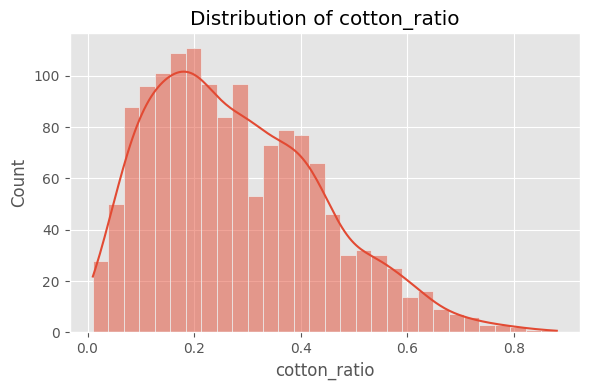

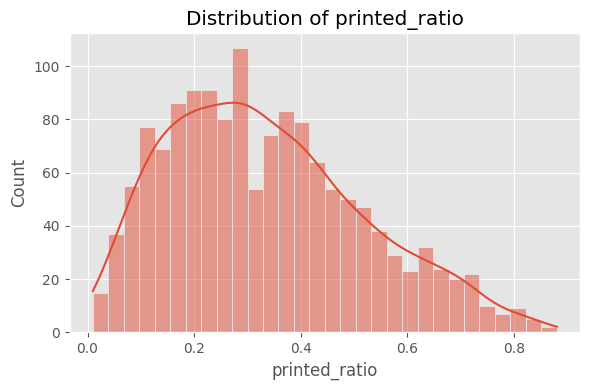

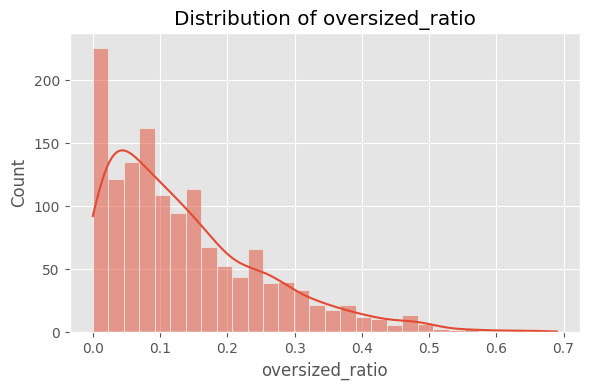

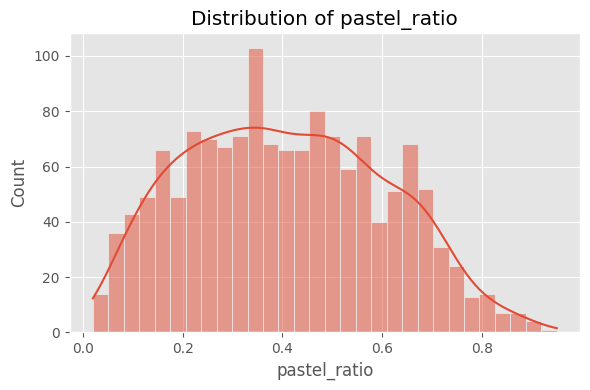

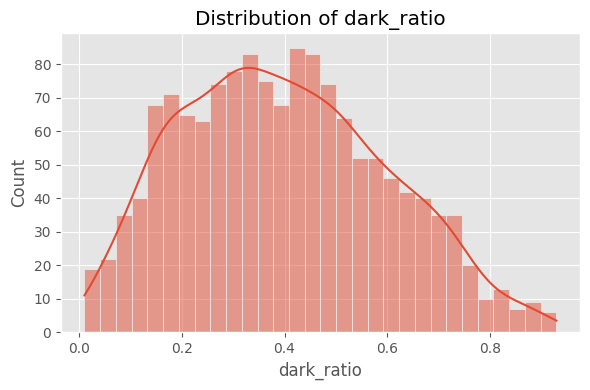

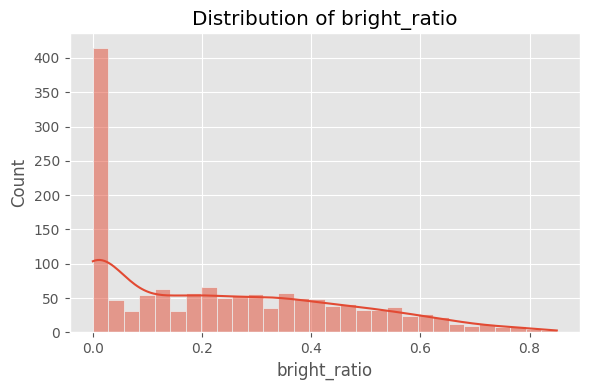

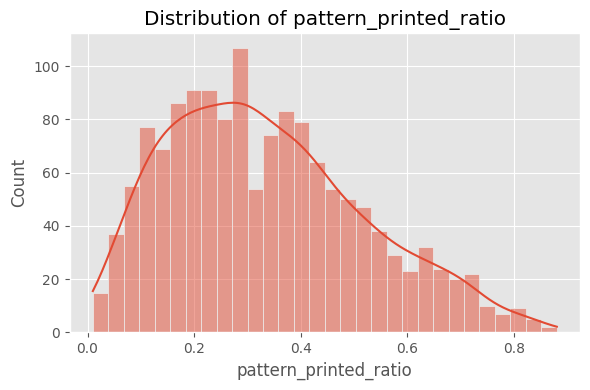

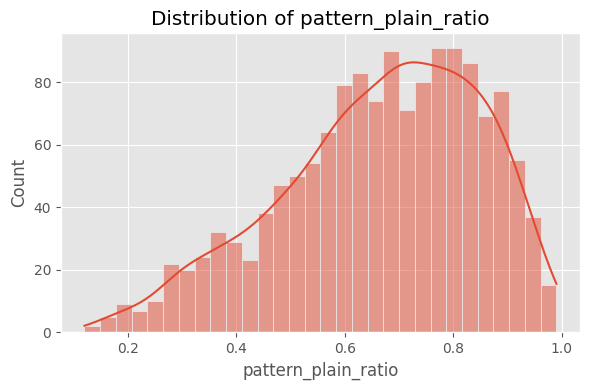

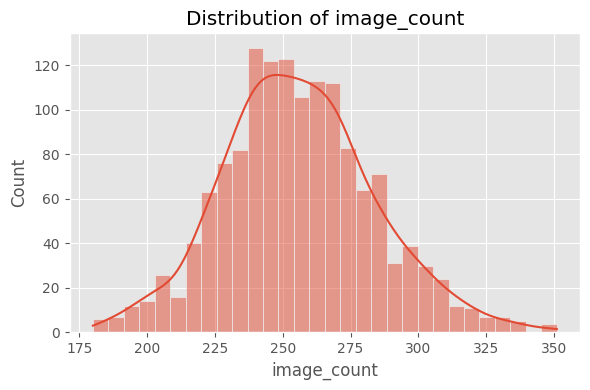

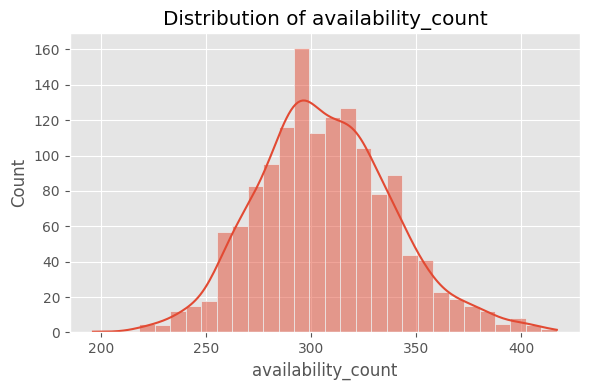

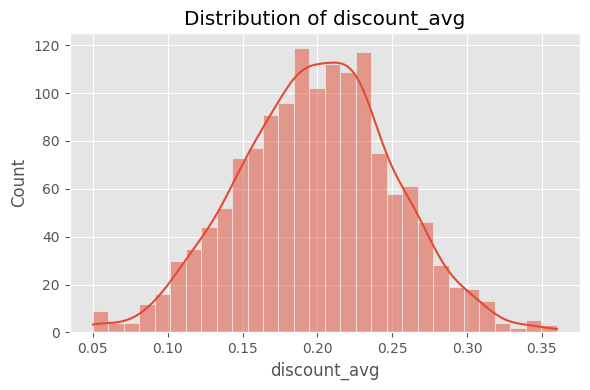

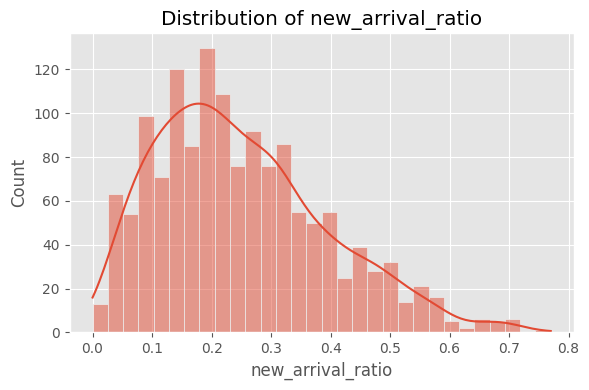

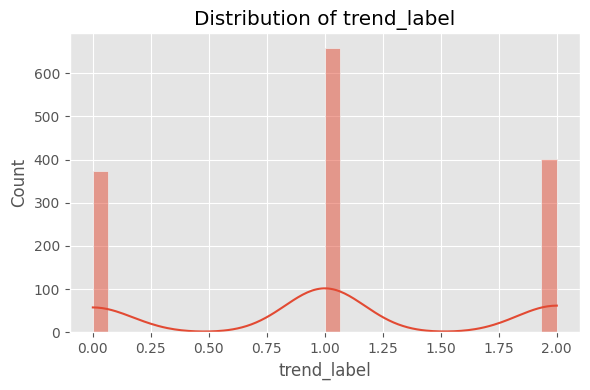

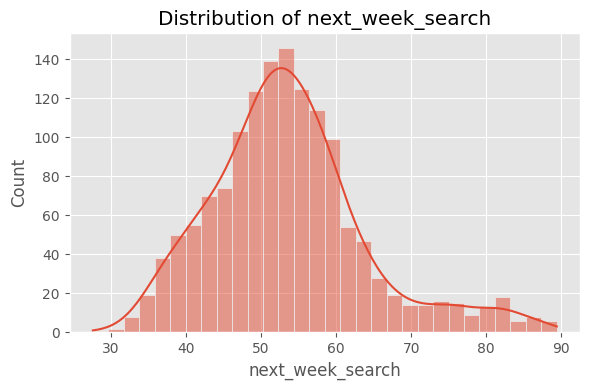

In [62]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")

    plt.tight_layout()

    plt.savefig(f"../reports/hist_{col}.png")

    plt.show()

    plt.close()

### Interpretation of Numerical Feature Distributions

The histogram analysis reveals several important characteristics of the dataset’s numerical variables.

**Temporal features** such as `week`, `year`, and `month` show uniform distributions, which is expected since the dataset represents weekly observations across multiple years. These variables primarily capture time structure rather than demand patterns.

**Demand and search-related features** including `search_index`, `keyword_frequency`, `momentum_4w`, `image_count`, and `availability_count` exhibit approximately bell-shaped distributions. This indicates that most observations cluster around a central range, reflecting relatively stable consumer interest levels with occasional fluctuations.

The feature **search_growth** is centered around zero, indicating that weekly demand changes are usually small, with both positive and negative variations occurring naturally.

**Price-related features**, particularly `avg_price`, display a strong right-skewed distribution. Most products fall within a typical mid-price range, while a small number of premium products create a long right tail.

**Style ratio features** (`cotton_ratio`, `printed_ratio`, `oversized_ratio`, `pastel_ratio`, `dark_ratio`, `bright_ratio`, `pattern_printed_ratio`, `pattern_plain_ratio`) are bounded between 0 and 1. These variables display different distribution shapes depending on how frequently each style appears in the dataset. Some styles appear rarely, resulting in distributions concentrated toward lower values.

The feature **discount_avg** follows a fairly smooth distribution centered around moderate discount levels, suggesting that most products receive similar discount ranges.

The variable **new_arrival_ratio** shows a right-skewed pattern, indicating that most weeks contain a moderate proportion of new arrivals, with fewer cases of very high product introduction rates.

The categorical target **trend_label** shows three distinct classes representing declining, stable, and rising trends. The distribution indicates that stable trends occur slightly more frequently than the other two categories.

Finally, **next_week_search**, which represents the regression target, displays a near-normal distribution centered around the mid-range of search demand values. This suggests that the forecasting target behaves in a relatively stable and predictable manner.

Overall, the distributions indicate that most features are well-behaved and suitable for machine learning models, although certain variables such as `avg_price` exhibit skewness that may require transformation or robust scaling during preprocessing.


### Outlier Detection Using Boxplots

Boxplots are used to detect potential outliers in numerical features.

Outliers represent observations that lie significantly outside the typical range of the data. These extreme values can influence machine learning models and may require treatment during preprocessing.

This step visualizes the spread and potential outliers for each numerical variable.


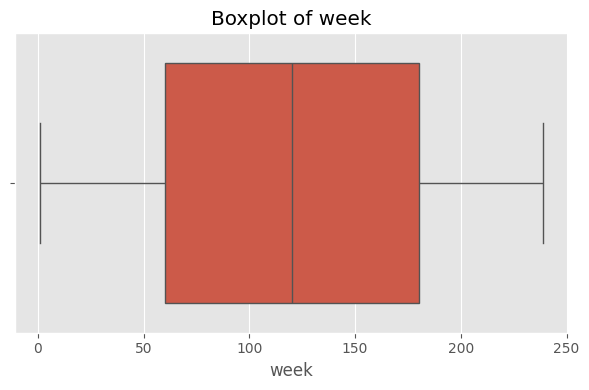

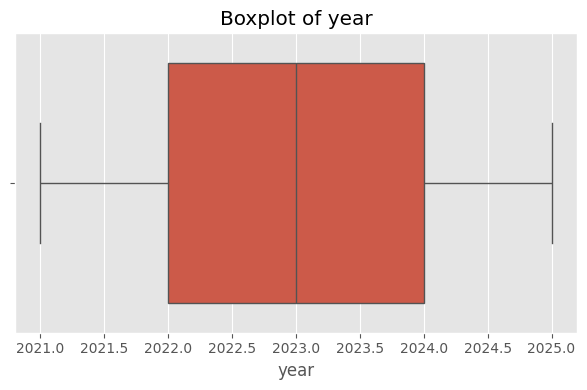

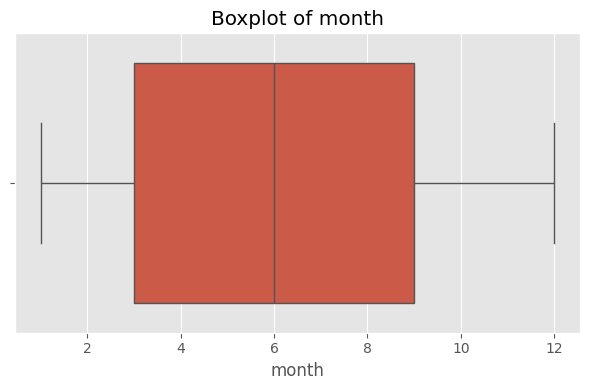

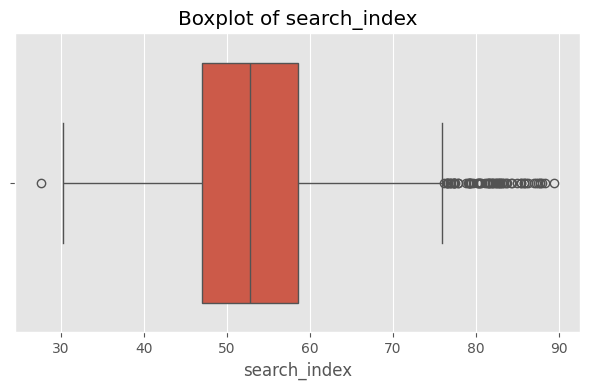

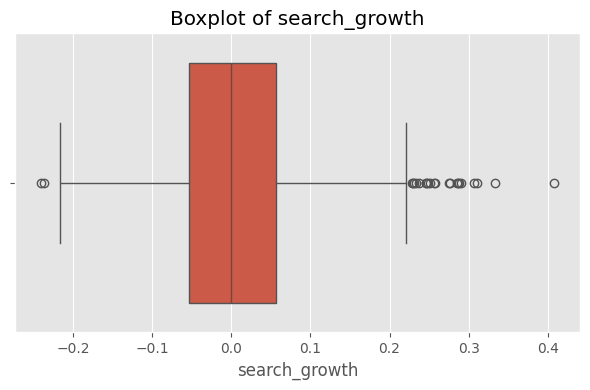

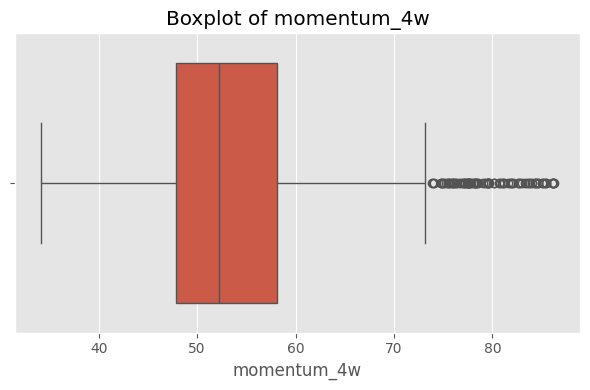

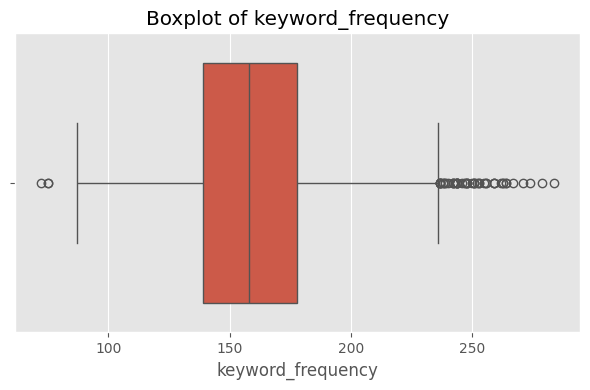

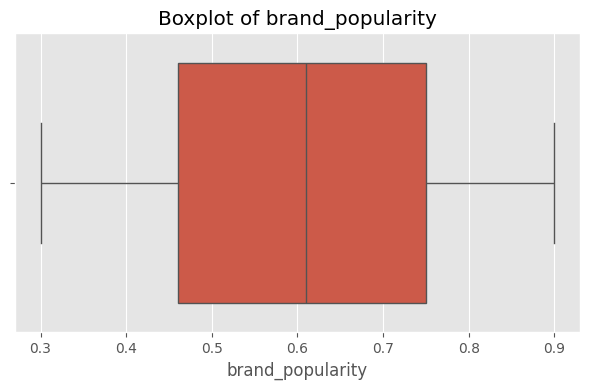

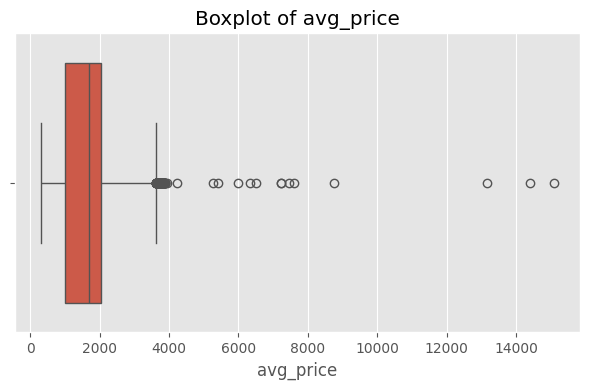

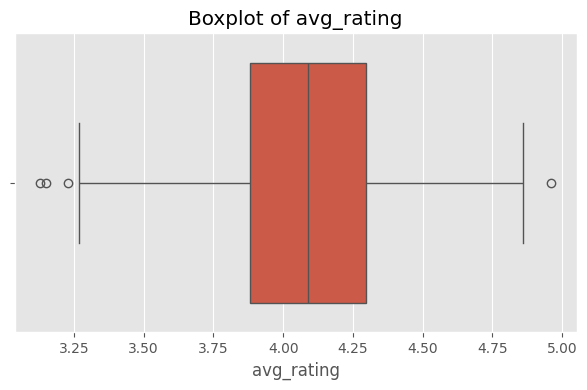

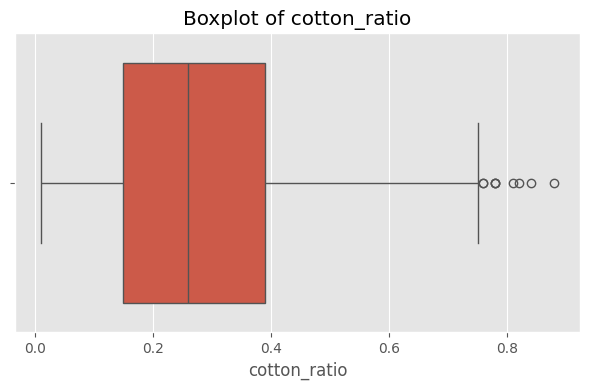

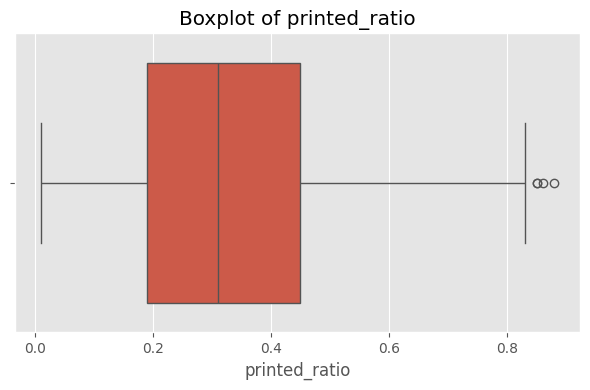

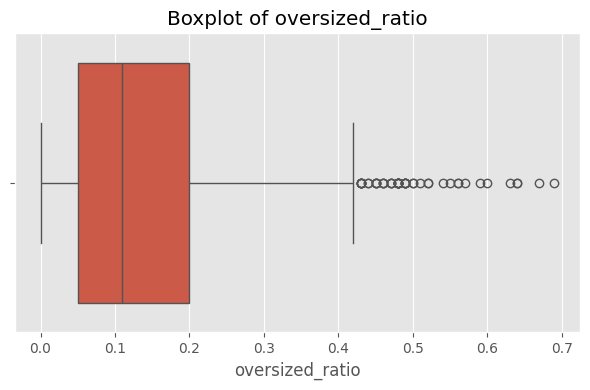

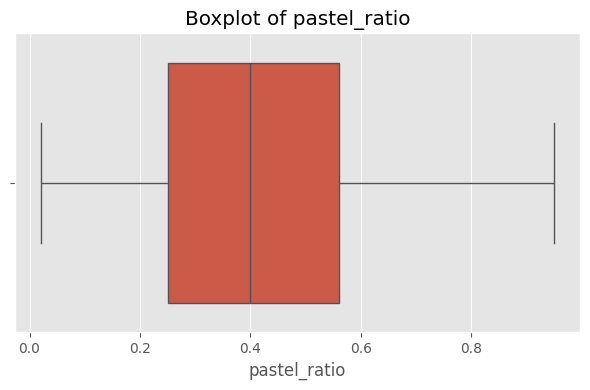

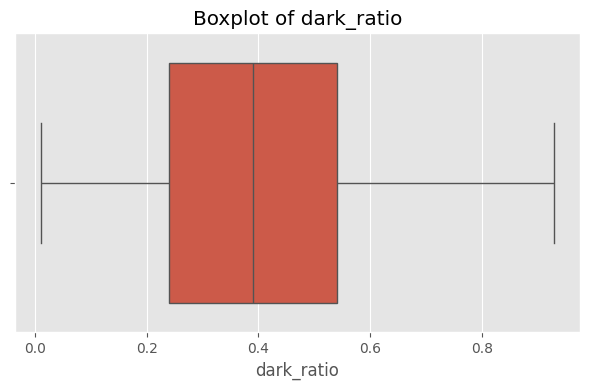

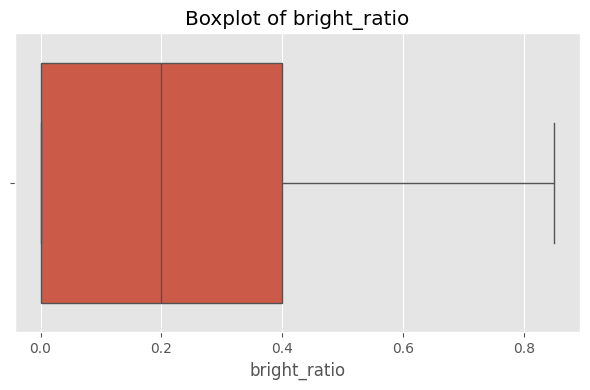

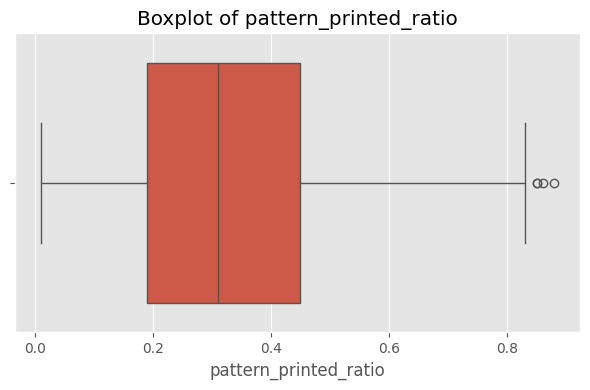

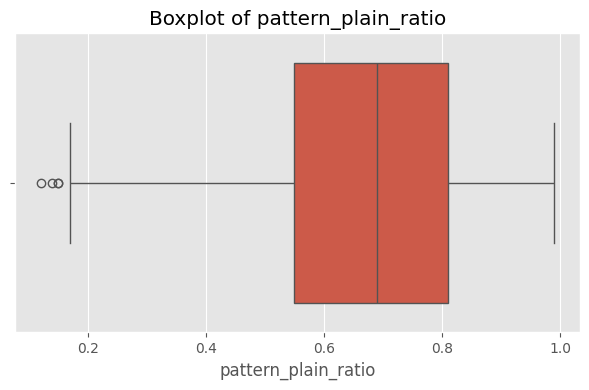

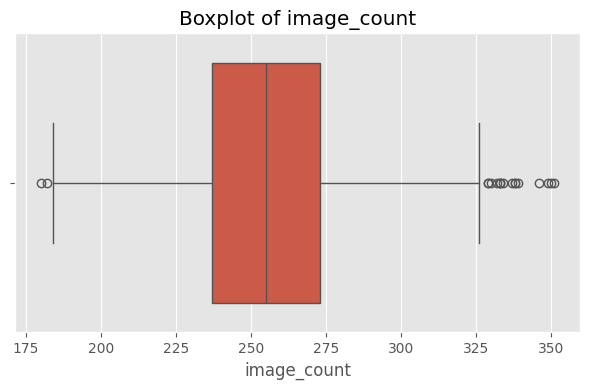

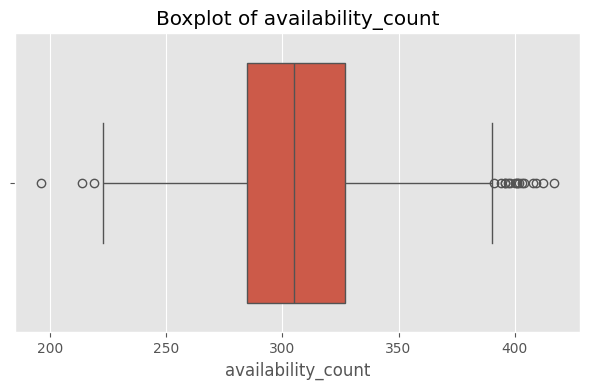

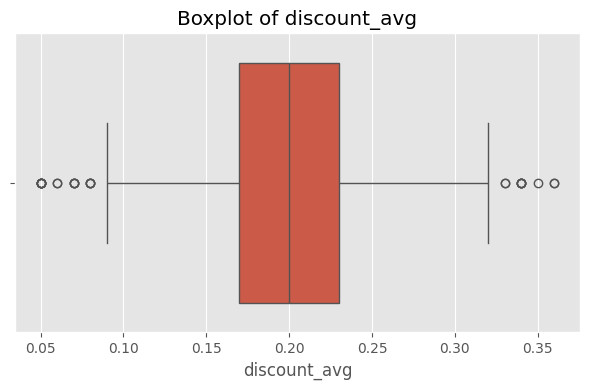

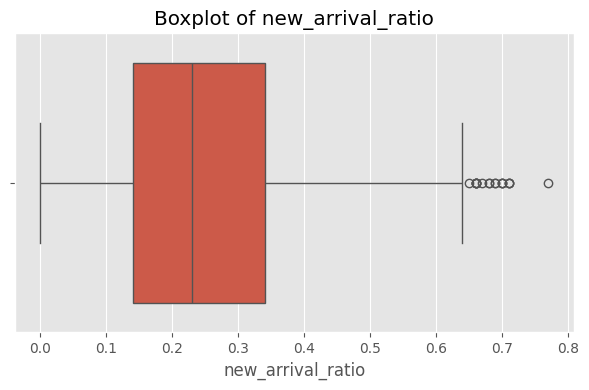

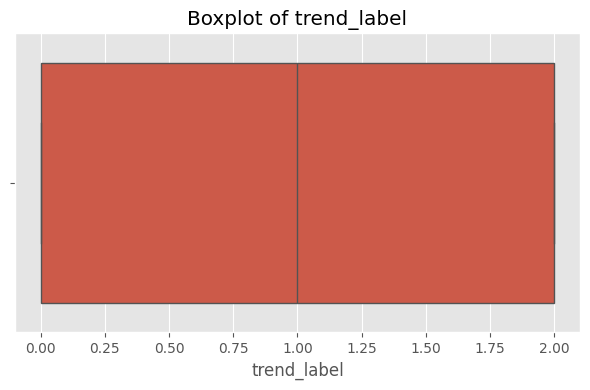

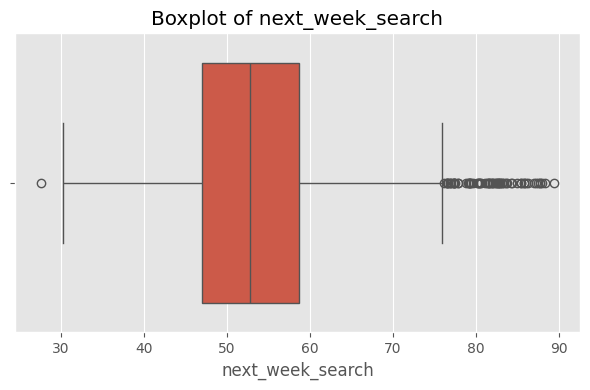

In [63]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.savefig(f"../reports/boxplot_{col}.png")

    plt.show()
    plt.close()

### Interpretation of Boxplot Analysis (Outlier Detection)

Boxplots were used to examine the spread of numerical variables and detect potential outliers across the dataset.

**Temporal variables (`week`, `year`, `month`)** show no meaningful outliers. This is expected because these variables represent structured calendar values rather than behavioral measurements.

Several **demand-related variables** such as `search_index`, `search_growth`, `momentum_4w`, and `keyword_frequency` exhibit moderate outliers on the higher end. These values likely correspond to weeks where a fashion category experienced sudden spikes in online interest due to seasonal demand, marketing campaigns, or viral fashion trends.

The **price variable (`avg_price`) displays the strongest outliers in the dataset**, with a long right tail extending to very high price values. Most products fall within a moderate price range, while a small number of luxury or premium items create extreme values. This behavior is typical in e-commerce datasets.

The **rating feature (`avg_rating`) shows a tight distribution** around the 4–4.5 range with only a few mild outliers, indicating that most products maintain relatively high customer satisfaction levels.

Several **style composition features** (`cotton_ratio`, `printed_ratio`, `oversized_ratio`, `pattern_printed_ratio`, `pattern_plain_ratio`) contain upper-bound outliers. Since these variables represent ratios between 0 and 1, such outliers likely correspond to weeks where a specific style dominated product listings within a category.

Marketplace activity indicators such as **`image_count` and `availability_count`** also contain high-end outliers. These values may represent periods when a category received unusually high numbers of product uploads or listings.

The newly analyzed variables show similar behavior:

* **`discount_avg`** displays mild outliers on both lower and higher ends of the distribution. This suggests that most weeks offer moderate discount levels, while a few periods experience unusually aggressive promotional pricing or minimal discounting.

* **`new_arrival_ratio`** shows right-side outliers where the proportion of new products becomes unusually high. These spikes may correspond to seasonal launches, new fashion collections, or major catalog refresh periods.

Overall, the majority of outliers observed across variables appear to represent **genuine market dynamics rather than data errors**. In fashion and e-commerce datasets, sudden spikes in price, product listings, demand, or promotional activity are common and reflect real-world behavior.

Therefore, these outliers should **not be removed prematurely**. Instead, appropriate scaling techniques or robust machine learning models can be applied later during the modeling stage to handle these variations effectively.


### Feature Relationship with Target Variables

In this section, we analyze how input features relate to the prediction targets.

Two prediction tasks exist in the dataset:

• **Trend Classification (`trend_label`)** – predicting whether a fashion category will decline, remain stable, or grow.
• **Demand Forecasting (`next_week_search`)** – predicting the numerical search interest for the next week.

Understanding how features relate to these targets helps identify which variables contain predictive information. Visualization techniques such as boxplots and scatter plots allow us to observe whether certain feature values correspond to particular trend behaviors or future demand levels.


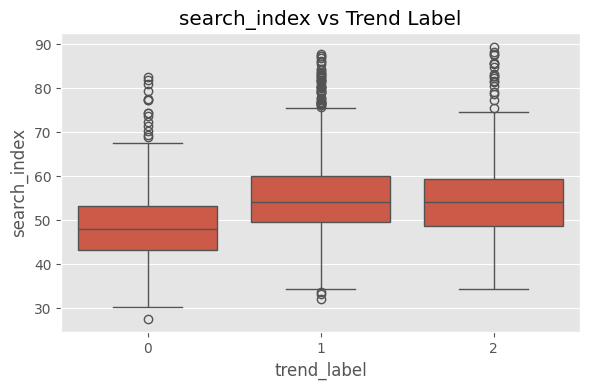

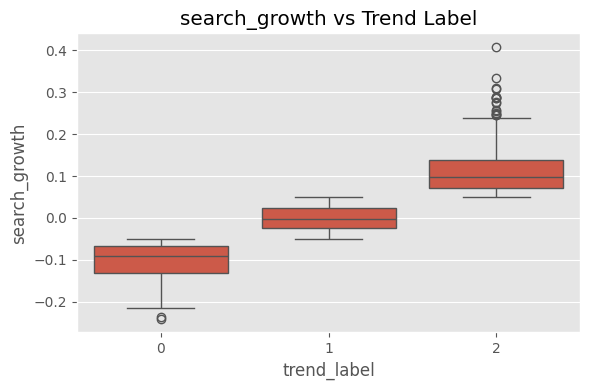

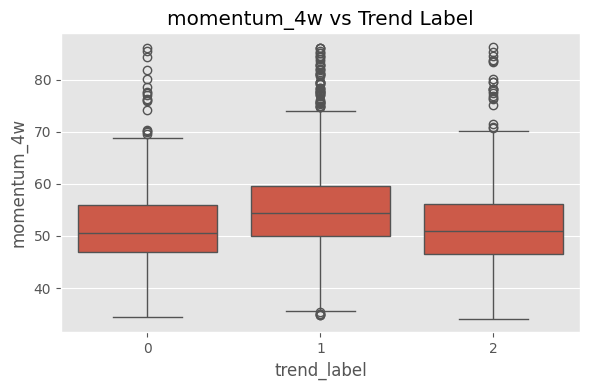

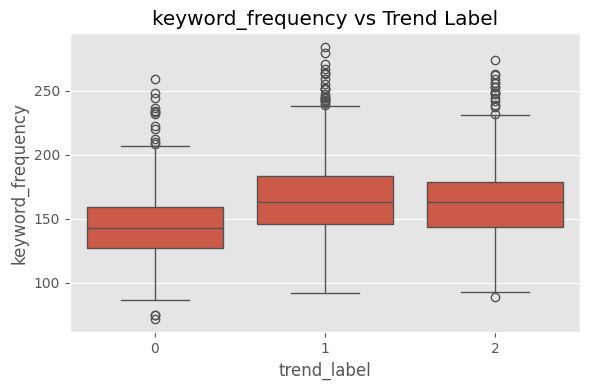

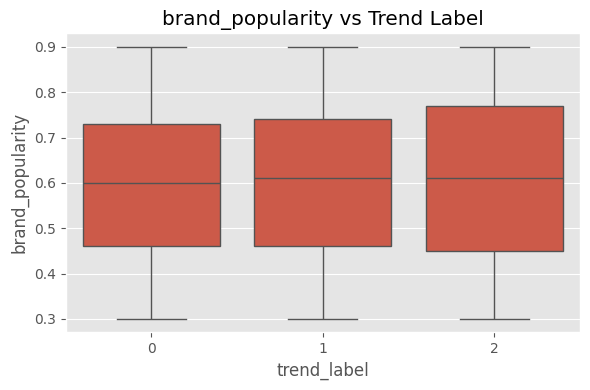

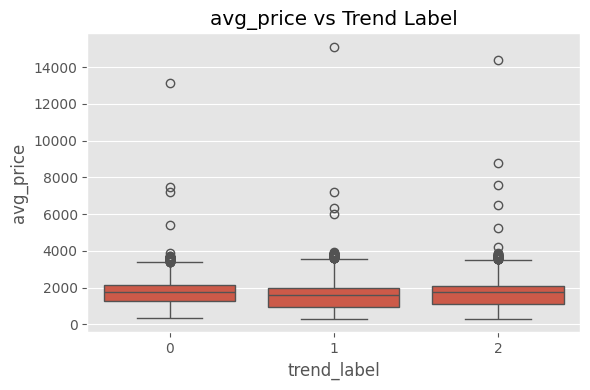

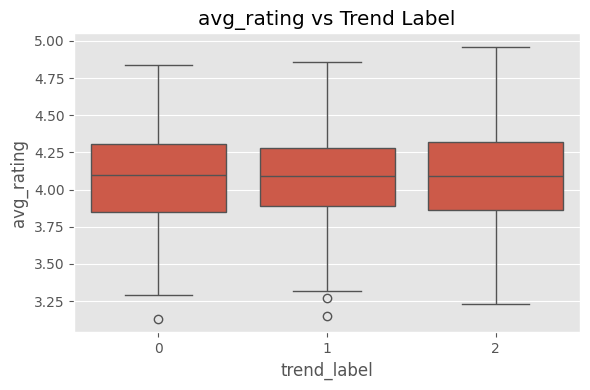

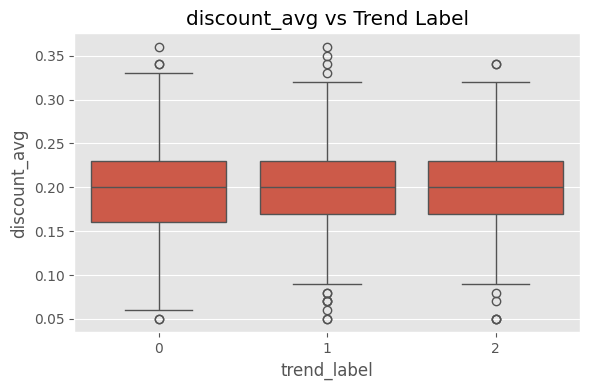

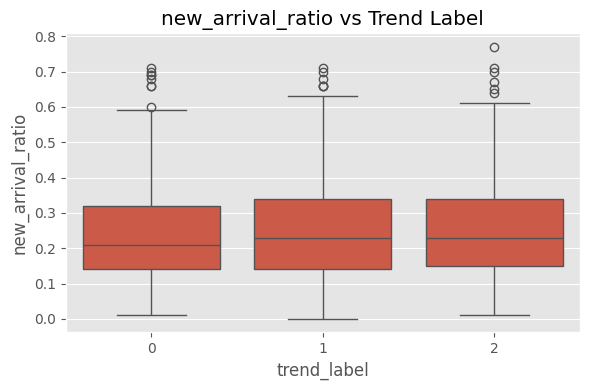

In [64]:
important_features = [
    "search_index",
    "search_growth",
    "momentum_4w",
    "keyword_frequency",
    "brand_popularity",
    "avg_price",
    "avg_rating",
    "discount_avg",
    "new_arrival_ratio"
]

for col in important_features:

    plt.figure(figsize=(6,4))
    sns.boxplot(x="trend_label", y=col, data=df)

    plt.title(f"{col} vs Trend Label")

    plt.tight_layout()
    plt.savefig(f"../reports/{col}_vs_trend_label.png")

    plt.show()
    plt.close()

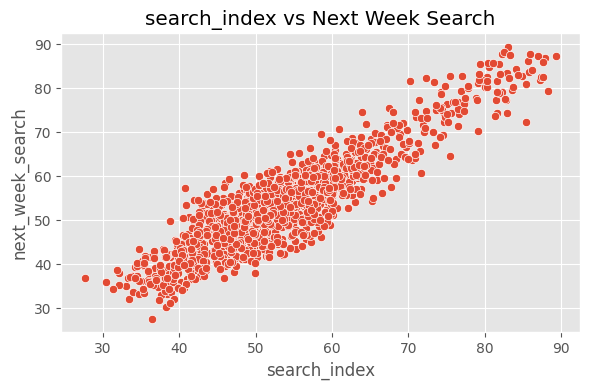

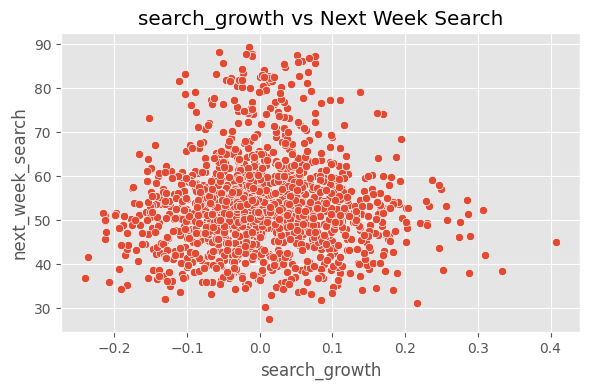

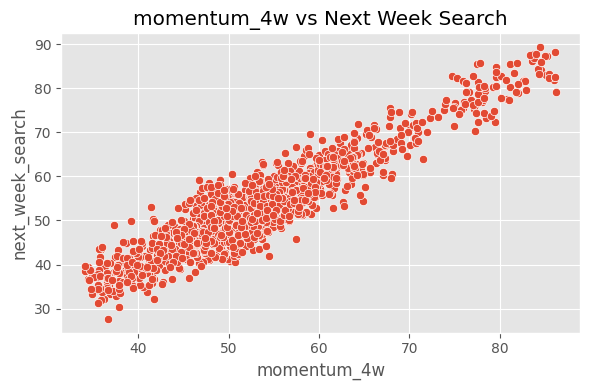

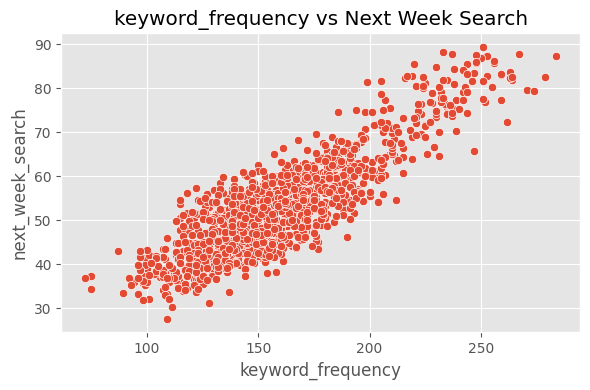

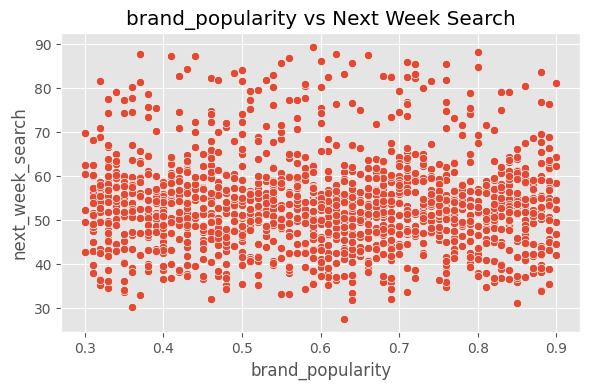

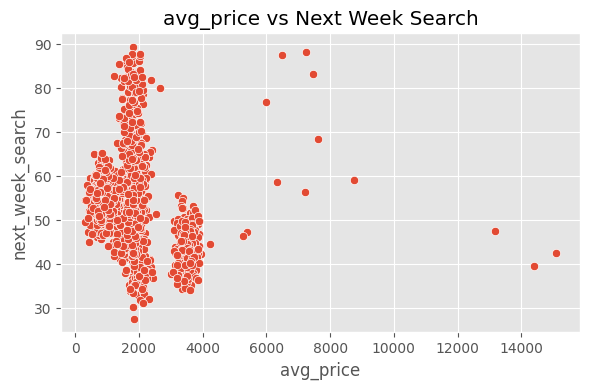

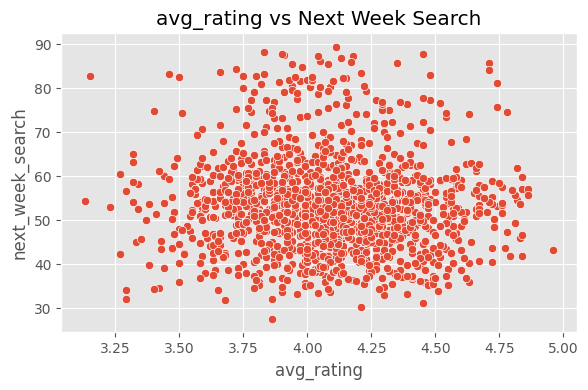

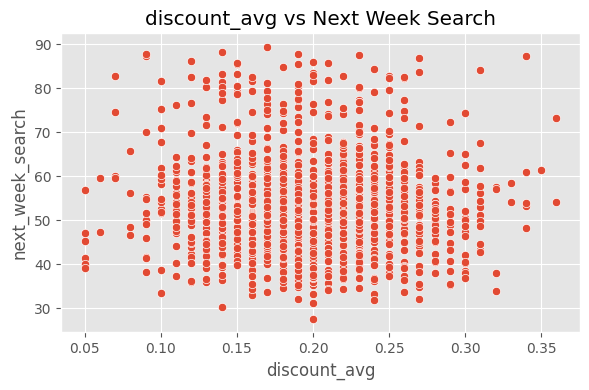

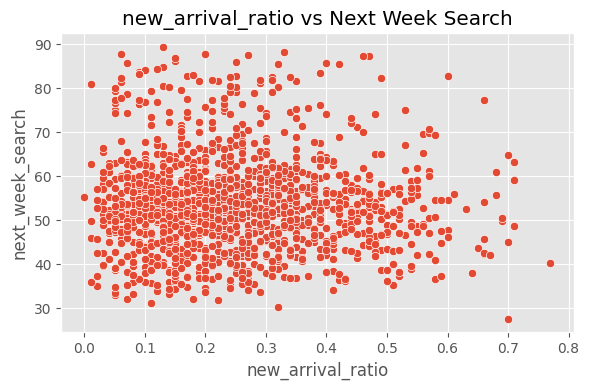

In [65]:
for col in important_features:

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["next_week_search"])

    plt.title(f"{col} vs Next Week Search")

    plt.tight_layout()
    plt.savefig(f"../reports/{col}_vs_next_week_search.png")

    plt.show()
    plt.close()

### Feature Relationship with Target Variables

To understand which variables influence fashion trend dynamics, we analyzed the relationship between features and the two prediction targets: `trend_label` (classification) and `next_week_search` (regression).

#### Relationship with Trend Label

Several variables show clear separation across trend categories:

* **Search Growth (`search_growth`)** shows the strongest relationship with trend labels. Negative values are associated with declining trends, values around zero correspond to stable trends, and positive values correspond to rising trends. This indicates that short-term growth in search activity is a strong indicator of fashion trend direction.

* **Search Index (`search_index`)** gradually increases from trend class 0 to class 2. Higher search demand levels are therefore associated with rising trends.

* **Keyword Frequency (`keyword_frequency`)** also increases slightly for higher trend classes, suggesting that higher online discussion or keyword mentions are associated with growing trends.

* **Momentum (`momentum_4w`)** shows moderate separation between classes, indicating that sustained interest over the past weeks contributes to trend formation.

Some variables show weak relationships with the trend class:

* **Brand Popularity**
* **Average Price**
* **Average Rating**
* **Average Discount**

These variables appear relatively similar across trend categories, indicating that they may have limited direct influence on trend direction.

The **new arrival ratio** shows a slight increase in higher trend classes, suggesting that categories with more new product launches may be more likely to experience growing trends.

#### Relationship with Future Demand (`next_week_search`)

Scatter plots reveal which features help predict future search demand.

Strong positive relationships are observed for:

* **Search Index**
* **Momentum (4-week trend)**
* **Keyword Frequency**

These variables show clear linear relationships with next week’s search demand, indicating strong predictive potential.

Weak or no clear relationships appear for:

* **Brand Popularity**
* **Average Rating**
* **Discount Level**
* **New Arrival Ratio**

These features appear more scattered and may have weaker predictive influence on future demand.

Overall, the analysis suggests that **search behavior indicators and historical momentum are the most important drivers of future fashion trends**, while pricing and brand-related variables play a smaller role in predicting short-term demand changes.
